# gradient descent

In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import cross_val_score

In [2]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1, n_targets=1,noise=20,random_state=13)

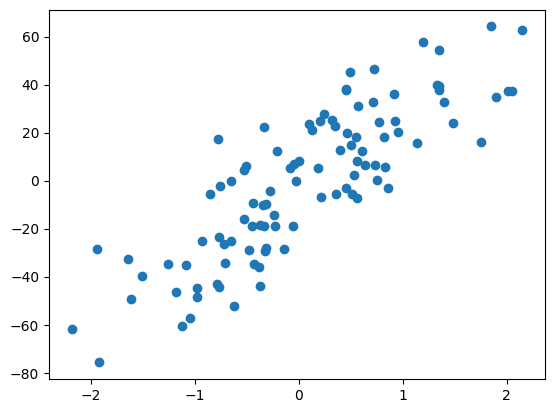

In [3]:
plt.scatter(X,y)

In [4]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [5]:
from sklearn.linear_model import LinearRegression

In [6]:
lr=LinearRegression()
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [7]:
print(lr.coef_)
print(lr.intercept_)

[28.12597332]
-2.2710144261783825


In [8]:
y_pred=lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012

In [1]:
# calculating both b and m.

In [9]:
class GDregressor:

    def __init__(self,learning_rate,epochs):
        self.m=100
        self.b=-120
        self.lr=learning_rate
        self.epochs=epochs

    def fit(self,X,y):
       # calculate m and b using GD
       for i in range(self.epochs):
           loss_slope_b=-2*np.sum(y-(self.m*X.ravel())-self.b)  # for b
           loss_slope_m=-2*np.sum((y-(self.m*X.ravel())-self.b)*X.ravel())
           
           self.b=self.b-(self.lr*loss_slope_b)
           self.m=self.m-(self.lr*loss_slope_m)
           # print(i,loss_slope,self.b)
           
       print(self.m,self.b)

    def predict(self,X):
        return self.m*X + self.b
           

In [10]:
gd=GDregressor(0.001,50)

In [11]:
gd.fit(X_train,y_train)

28.159367347119066 -2.3004574196824854


In [12]:
gd.predict(X_test)

array([[ 21.09732023],
       [ 18.02962184],
       [ 18.23238093],
       [ -8.13929374],
       [ 15.71827044],
       [ 58.2529665 ],
       [-15.07783741],
       [-11.37125581],
       [-15.85557195],
       [ -8.84542293],
       [-23.62986105],
       [ 14.77224759],
       [ 12.68984073],
       [-23.94450805],
       [-22.36092777],
       [-16.71707058],
       [ 24.53064978],
       [-17.03243073],
       [ -3.92053306],
       [-12.06068528]])

In [13]:
y_pred=lr.predict(X_test)
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.6345158782661012